In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from scipy.interpolate import interp1d
from matplotlib.colors import TwoSlopeNorm

plt.rcParams.update({
    'figure.dpi': 120, 'axes.grid': True, 'grid.alpha': 0.3,
    'axes.titlesize': 13, 'axes.labelsize': 11, 'font.family': 'DejaVu Sans'
})


---
## Step 1 — Load Data


In [ ]:
df  = pd.read_excel("Magnetic data.xlsx", sheet_name="Raw_data")
df2 = pd.read_excel("Magnetic data.xlsx", sheet_name="Base_station")

df['TIME'] = pd.to_datetime(df['TIME'].astype(str), format='%H:%M:%S')

print(" Field Survey  —", df.shape)
print(df.head())
print()
print(" Base Station  —", df2.shape)
print(df2.head())


📋 Field Survey  — (100, 3)
                 TIME   RAW-MAG     IGRF
0 1900-01-01 08:44:00  46621.14  46381.2
1 1900-01-01 08:48:00  46595.78  46388.8
2 1900-01-01 08:52:00  46642.70  46396.4
3 1900-01-01 08:56:00  46687.13  46404.0
4 1900-01-01 09:00:00  46703.25  46411.5

📋 Base Station  — (451, 4)
   TIME-H  TIME-M  TIME-S  BASE-MAG-READINGS
0       8      30       2          46653.128
1       8      31       2          46652.628
2       8      32       2          46652.028
3       8      33       2          46652.028
4       8      34       2          46651.628


---
## Step 1A — Raw Field & Computed Variables


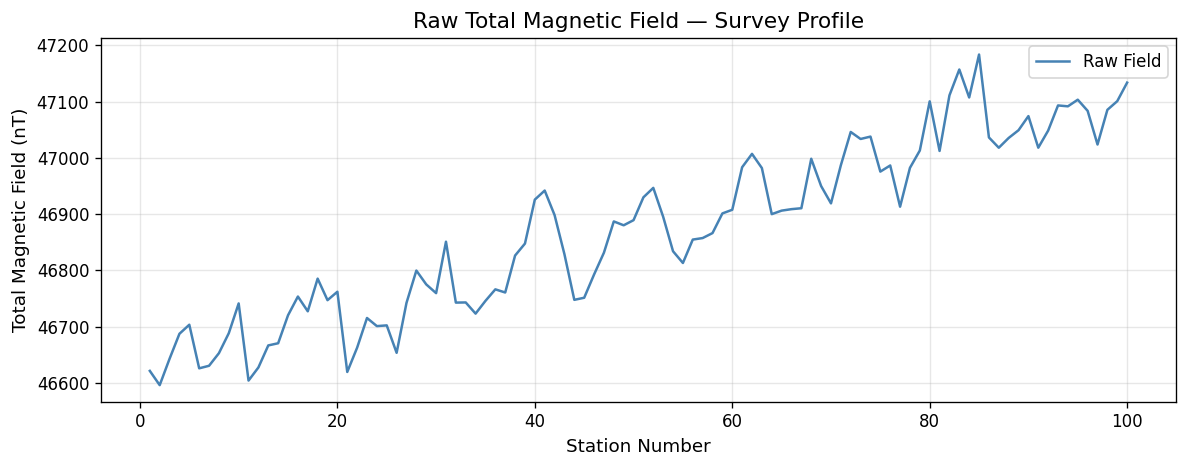

RAW-MAG range: 46595.8 – 47183.9 nT


In [ ]:
#Variables
time = (df['TIME'].dt.hour
        + df['TIME'].dt.minute / 60
        + df['TIME'].dt.second / 3600)   # decimal hours (used only for drift calculation)

raw  = df['RAW-MAG'].values              # Raw magnetometer readings (nT)
igrf = df['IGRF'].values                 # Absolute IGRF model values (nT)

station_no = np.arange(1, len(raw) + 1) # Station numbers 1 → 100 (x-axis for all plots)
base_time  = df2['TIME-H'] + df2['TIME-M']/60 + df2['TIME-S']/3600  # base station time

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(station_no, raw, color='steelblue', linewidth=1.5, label='Raw Field')
ax.set_xlabel("Station Number")
ax.set_ylabel("Total Magnetic Field (nT)")
ax.set_title("Raw Total Magnetic Field — Survey Profile")
ax.legend()
plt.tight_layout()
plt.show()
print(f"RAW-MAG range: {raw.min():.1f} – {raw.max():.1f} nT")


---
## Step 2 — Diurnal Correction (Drift-Based Method)



Base start    : 46653.128 nT  at  8:30
Base end      : 46635.528 nT  at  16:00
Total drift   : -17.600 nT  over  7.50 hours
Drift rate    : -2.3467 nT / hour
DC range      : -0.16 – -0.16 nT


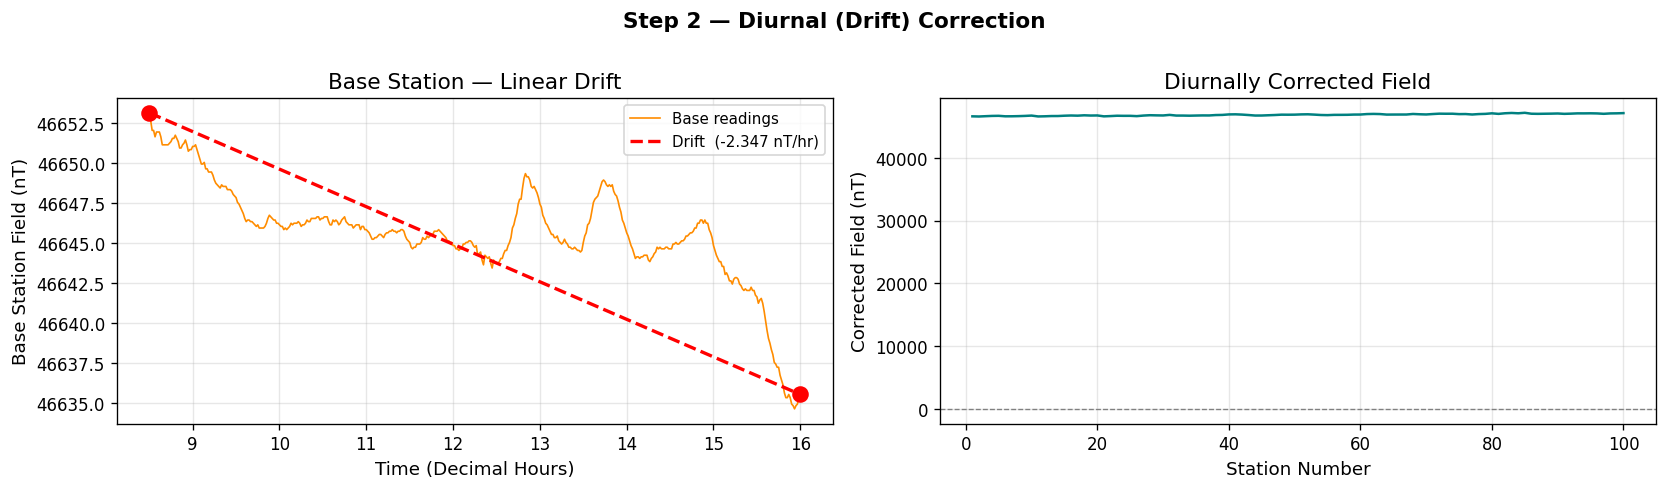

In [ ]:
# Drift-based diurnal correction
B_start    = df2['BASE-MAG-READINGS'].iloc[0]          # first base reading (nT)
B_end      = df2['BASE-MAG-READINGS'].iloc[-1]          # last  base reading (nT)
T_start    = base_time.iloc[0]                          # start time (decimal hours)
T_end      = base_time.iloc[-1]                         # end   time (decimal hours)

drift_rate = (B_end - B_start) / (T_end - T_start)     # nT / hour
dt         = time.iloc[1] - time.iloc[0]
dc = drift_rate*dt
dcf= raw-dc

print(f"Base start    : {B_start:.3f} nT  at  {df2['TIME-H'].iloc[0]:.0f}:{df2['TIME-M'].iloc[0]:02.0f}")
print(f"Base end      : {B_end:.3f} nT  at  {df2['TIME-H'].iloc[-1]:.0f}:{df2['TIME-M'].iloc[-1]:02.0f}")
print(f"Total drift   : {B_end - B_start:.3f} nT  over  {T_end - T_start:.2f} hours")
print(f"Drift rate    : {drift_rate:.4f} nT / hour")
print(f"DC range      : {dc.min():.2f} – {dc.max():.2f} nT")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Base station with drift line
drift_line = B_start + drift_rate * (base_time - T_start)
axes[0].plot(base_time, df2['BASE-MAG-READINGS'], color='darkorange', lw=1, label='Base readings')
axes[0].plot(base_time, drift_line, 'r--', lw=2, label=f'Drift  ({drift_rate:.3f} nT/hr)')
axes[0].scatter([T_start, T_end], [B_start, B_end], s=80, c='red', zorder=5)
axes[0].set_xlabel("Time (Decimal Hours)")
axes[0].set_ylabel("Base Station Field (nT)")
axes[0].set_title("Base Station — Linear Drift")
axes[0].legend(fontsize=9)

# Drift correction applied at each station
axes[1].plot(station_no, dcf, color='teal', lw=1.5)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel("Station Number")
axes[1].set_ylabel("Corrected Field (nT)")
axes[1].set_title("Diurnally Corrected Field")

plt.suptitle("Step 2 — Diurnal (Drift) Correction", fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


---
## Step 3 — IGRF Correction


In [ ]:
# IGRF Correction
      # IGRF variation along profile
anomaly   = dcf - igrf      # Total Field Magnetic Anomaly ΔF


---
## Step 4 — Magnetic Anomaly Profile

The **total field magnetic anomaly** $\Delta F$ plotted against station number.
Positive values (red) indicate more magnetically susceptible rock beneath that station.
Negative values (blue) indicate less magnetic rock relative to the regional field.


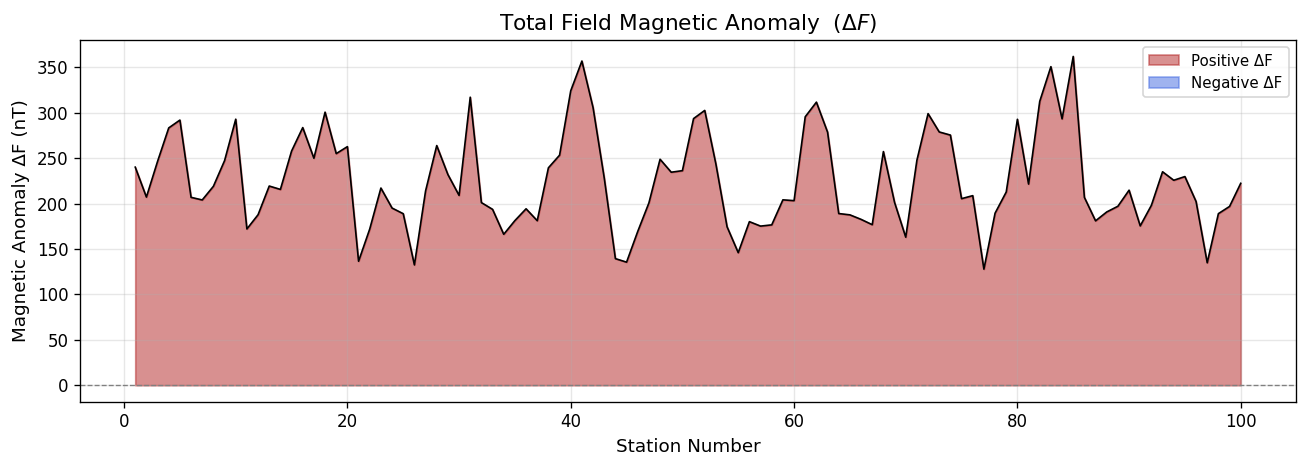

In [ ]:
# Magnetic anomaly profile vs station number
plt.figure(figsize=(11, 4))
plt.fill_between(station_no, anomaly, 0, where=(anomaly >= 0), interpolate=True,
                 color='firebrick', alpha=0.5, label='Positive ΔF')
plt.fill_between(station_no, anomaly, 0, where=(anomaly < 0), interpolate=True,
                 color='royalblue', alpha=0.5, label='Negative ΔF')
plt.plot(station_no, anomaly, 'k-', lw=1.0)
plt.axhline(0, color='gray', ls='--', lw=0.8)
plt.xlabel("Station Number")
plt.ylabel("Magnetic Anomaly ΔF (nT)")
plt.title("Total Field Magnetic Anomaly  ($\\Delta F$)")
plt.legend(fontsize=9)
plt.tight_layout()
plt.show()


---
## Full Correction Summary (All Stages)


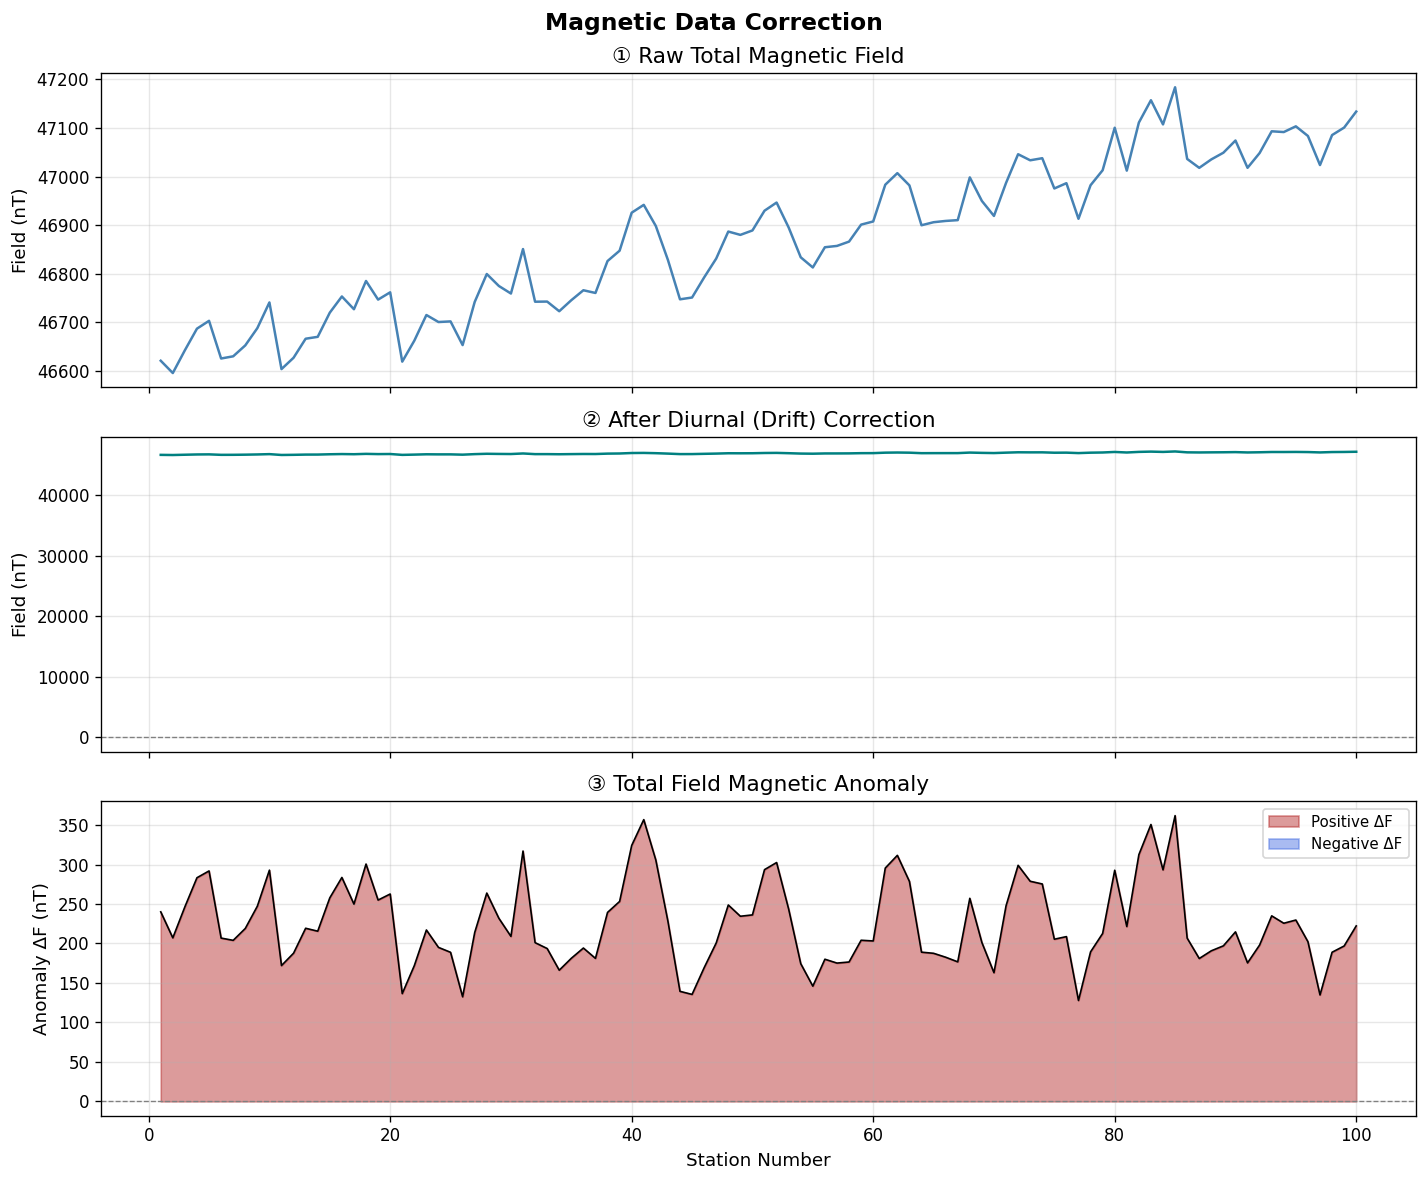

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

axes[0].plot(station_no, raw, color='steelblue', lw=1.5)
axes[0].set_ylabel("Field (nT)")
axes[0].set_title("① Raw Total Magnetic Field")
axes[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

axes[1].plot(station_no, dcf, color='teal', lw=1.5)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_ylabel("Field (nT)")
axes[1].set_title("② After Diurnal (Drift) Correction")

axes[2].fill_between(station_no, anomaly, 0, where=(anomaly >= 0), interpolate=True,
                     color='firebrick', alpha=0.45, label='Positive ΔF')
axes[2].fill_between(station_no, anomaly, 0, where=(anomaly < 0), interpolate=True,
                     color='royalblue', alpha=0.45, label='Negative ΔF')
axes[2].plot(station_no, anomaly, 'k-', lw=1.0)
axes[2].axhline(0, color='gray', ls='--', lw=0.8)
axes[2].set_xlabel("Station Number")
axes[2].set_ylabel("Anomaly ΔF (nT)")
axes[2].set_title("③ Total Field Magnetic Anomaly")
axes[2].legend(fontsize=9)

plt.suptitle("Magnetic Data Correction", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Step 5 — 1D Anomaly Profile Analysis

The survey data is a **single 1D profile** — 100 stations along a straight line
at 10 m spacing.


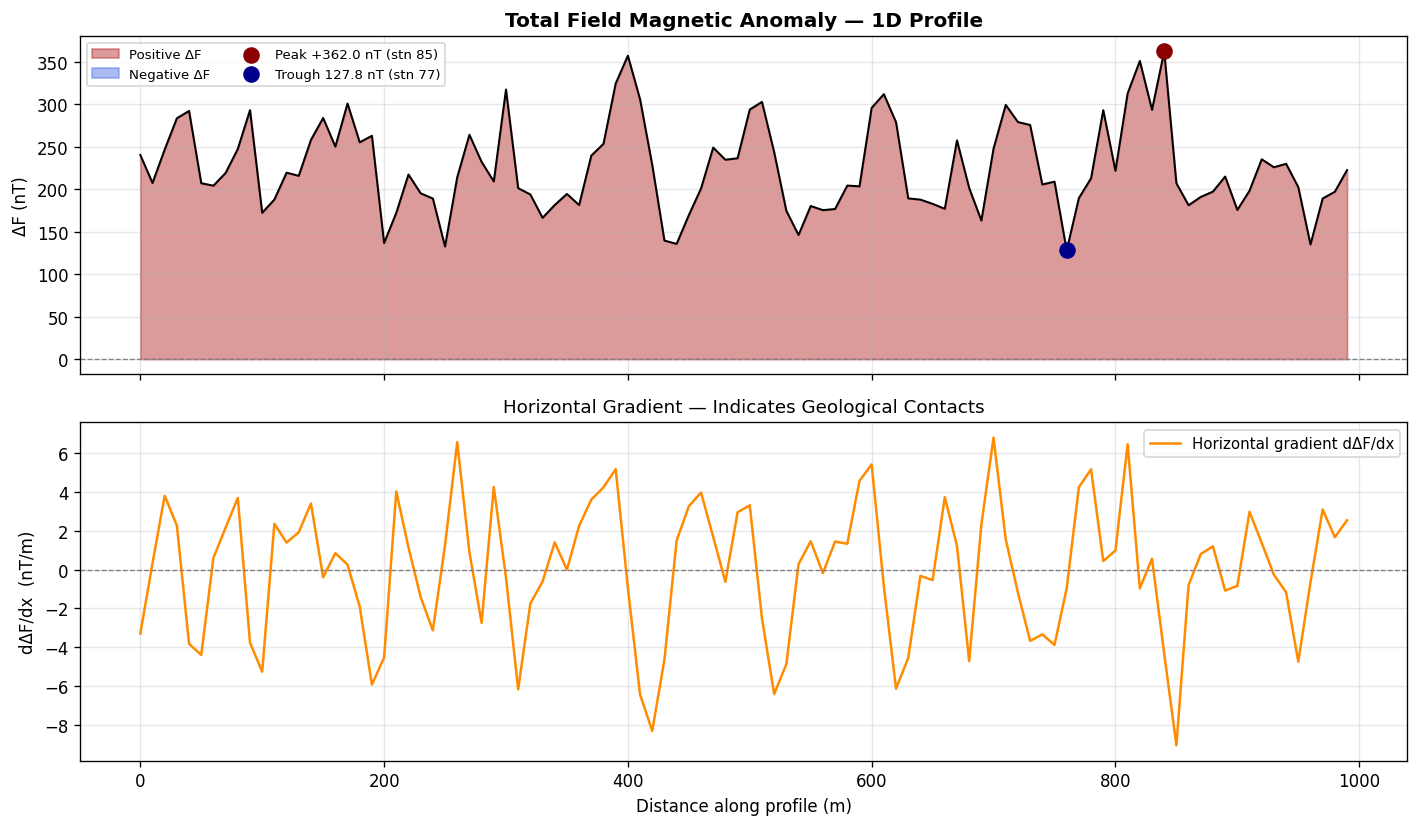

Peak anomaly    : +361.97 nT  at station 85  (840 m)
Trough anomaly  : 127.81 nT  at station 77  (760 m)
Peak gradient   : 9.050 nT/m  at station 86


In [ ]:
# 1D Anomaly Profile Analysis (replaces pseudo-2D contour map)
x_m = (station_no - 1) * 10.0    # distance in metres

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# Top: anomaly with fills
axes[0].fill_between(x_m, anomaly, 0, where=(anomaly >= 0), interpolate=True,
                     color='firebrick', alpha=0.45, label='Positive ΔF')
axes[0].fill_between(x_m, anomaly, 0, where=(anomaly < 0), interpolate=True,
                     color='royalblue', alpha=0.45, label='Negative ΔF')
axes[0].plot(x_m, anomaly, 'k-', lw=1.2)
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
# Mark peak and trough
axes[0].scatter(x_m[np.argmax(anomaly)], anomaly.max(), s=80, c='darkred',
                zorder=5, label=f'Peak +{anomaly.max():.1f} nT (stn {np.argmax(anomaly)+1})')
axes[0].scatter(x_m[np.argmin(anomaly)], anomaly.min(), s=80, c='darkblue',
                zorder=5, label=f'Trough {anomaly.min():.1f} nT (stn {np.argmin(anomaly)+1})')
axes[0].set_ylabel("ΔF (nT)", fontsize=10)
axes[0].set_title("Total Field Magnetic Anomaly — 1D Profile", fontsize=12, fontweight='bold')
axes[0].legend(fontsize=8, ncol=2)

# Bottom: horizontal gradient dΔF/dx
gradient_anom = np.gradient(anomaly, 10.0)   # nT/m
axes[1].plot(x_m, gradient_anom, color='darkorange', lw=1.5, label='Horizontal gradient dΔF/dx')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel("Distance along profile (m)", fontsize=10)
axes[1].set_ylabel("dΔF/dx  (nT/m)", fontsize=10)
axes[1].set_title("Horizontal Gradient — Indicates Geological Contacts", fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"Peak anomaly    : +{anomaly.max():.2f} nT  at station {np.argmax(anomaly)+1}  ({x_m[np.argmax(anomaly)]:.0f} m)")
print(f"Trough anomaly  : {anomaly.min():.2f} nT  at station {np.argmin(anomaly)+1}  ({x_m[np.argmin(anomaly)]:.0f} m)")
print(f"Peak gradient   : {np.abs(gradient_anom).max():.3f} nT/m  at station {np.abs(gradient_anom).argmax()+1}")


In [ ]:
print("   MAGNETIC ANOMALY — SUMMARY STATISTICS \n")
print(f"  Stations processed         : {len(anomaly)}")
print(f"  Station spacing            : 10 m  →  total profile {(len(anomaly)-1)*10} m")
print(f"  Drift rate                 : {drift_rate:.4f} nT / hour")
print(f"  Total drift over survey    : {B_end - B_start:.3f} nT")
print(f"  Max Positive Anomaly (+ΔF) : {anomaly.max():.2f} nT  (Station {np.argmax(anomaly)+1})")
print(f"  Mean Anomaly               : {anomaly.mean():.2f} nT")
print(f"  Std Deviation              : {anomaly.std():.2f} nT")


   MAGNETIC ANOMALY — SUMMARY STATISTICS 



NameError: name 'anomaly' is not defined

---
## Step 6 — Survey Geometry & Model Parameterisation


| Parameter | Value | Notes |
|---|---|---|
| Station spacing `dx` | 10 m | assumed for 100 stations |
| Number of depth layers | 20 | |
| Layer thickness `dz` | 15 m | → model depth 0 – 305 m |
| Inducing field `F₀` | mean IGRF | ~46,646 nT |
| Inclination `Inc` | 25° | Mumbai region, IGRF-13 |
| Declination `Dec` | −0.5° | Mumbai region, IGRF-13 |


In [ ]:
# Survey Geometry & Model Grid
from scipy.ndimage import uniform_filter1d

dx      = 10.0                            # station spacing (m)
x_obs   = np.arange(len(anomaly)) * dx   # surface x-coordinates (m)
n_obs   = len(anomaly)

n_layers = 20                             # number of depth layers
dz       = 15.0                           # layer thickness (m)
z_top    = np.arange(n_layers) * dz + 5  # top depth of each layer (m)
z_bot    = z_top + dz                     # bottom depth of each layer (m)
z_mid    = (z_top + z_bot) / 2.0         # centre depth (m)
hx       = dx / 2.0                       # prism half-width (m)
n_model  = n_obs * n_layers               # total number of unknowns

# ── Inducing field parameters (Mumbai region, IGRF-13) ───────────────────────
F0  = np.mean(igrf)           # mean total field intensity (nT)
Inc = np.radians(25.0)        # field inclination (degrees → radians)
Dec = np.radians(-0.5)        # field declination (degrees → radians)

# Effective inclination for 2D profile (profile assumed E-W)
Inc_eff = np.arctan(np.tan(Inc) / np.cos(Dec))

print("  MODEL PARAMETERISATION SUMMARY \n")
print(f"  Observation points : {n_obs}")
print(f"  Depth layers       : {n_layers}")
print(f"  Layer thickness    : {dz:.1f} m")
print(f"  Depth range        : {z_top[0]:.1f} – {z_bot[-1]:.1f} m")
print(f"  Total unknowns     : {n_model}")
print(f"  Inducing field F₀  : {F0:.1f} nT")
print(f"  Inclination        : {np.degrees(Inc):.1f}°")
print(f"  Effective Inc (2D) : {np.degrees(Inc_eff):.2f}°")
print(f"  Declination        : {np.degrees(Dec):.1f}°")


  MODEL PARAMETERISATION SUMMARY 

  Observation points : 100
  Depth layers       : 20
  Layer thickness    : 15.0 m
  Depth range        : 5.0 – 305.0 m
  Total unknowns     : 2000
  Inducing field F₀  : 46645.6 nT
  Inclination        : 25.0°
  Effective Inc (2D) : 25.00°
  Declination        : -0.5°


---
## Step 7 — Sensitivity Matrix G (Forward Kernel)


$$G_{ij} = \frac{\mu_0}{4\pi} \cdot 2F_0 \cdot \Big[\,
  l \cdot n \ln\!\left(\frac{r_2}{r_1}\right)
  + (l^2 - n^2) \arctan\!\left(\frac{x \cdot z}{r^2}\right)
  \Big]_{\text{evaluated at 4 prism corners}}$$




Building G (100 × 2000)  ...
 G built successfully
   Shape          : (100, 2000)
   Value range    : -6481185.18 – 3982459.55 nT/SI
   Condition no.  : 5.53e+00  (ill-posed → needs regularisation)
   Max singular σ : 1.3924e+07
   Min singular σ : 2.5192e+06


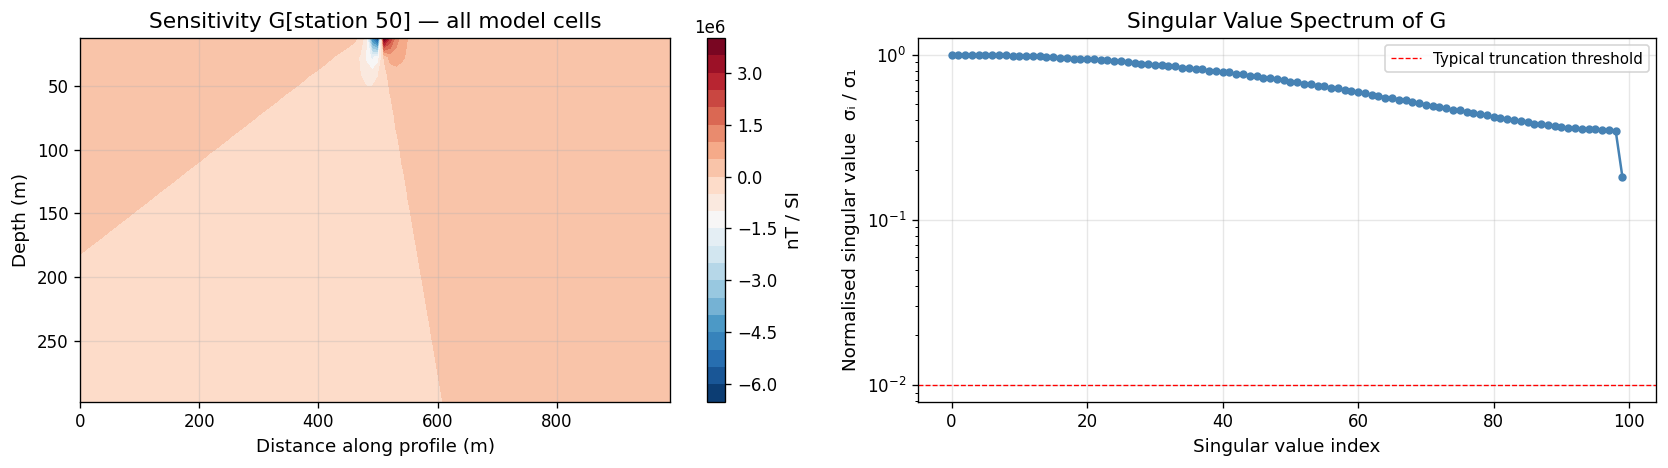

In [ ]:
# Build Sensitivity Matrix G

def G_kernel_2d(xi, xj, z1, z2, hx, Inc_eff, F0):
    """
    Total-field anomaly at surface point xi (z=0) due to a unit-susceptibility
    2D prism centred at xj, with top z1, bottom z2, half-width hx.

    Uses the Blakely (1995) 2D prism formula for induced magnetisation.

    Parameters
    ----------
    xi      : observation x-coordinate (m)
    xj      : prism centre x-coordinate (m)
    z1, z2  : prism top and bottom depth (m, positive downward)
    hx      : prism half-width (m)
    Inc_eff : effective field inclination for 2D profile (radians)
    F0      : inducing field intensity (nT)

    Returns
    -------
    kernel value in nT per SI unit of susceptibility
    """
    mu0_4pi = 1e-7                  # μ₀ / 4π  [T·m/A]
    l2 = np.cos(Inc_eff)            # horizontal field component
    n2 = np.sin(Inc_eff)            # vertical field component

    # Horizontal distances from observation point to prism left/right edges
    xa = xi - (xj - hx)            # distance to left edge
    xb = xi - (xj + hx)            # distance to right edge

    def kernel(x, z):
        r2 = x**2 + z**2
        if r2 < 1e-10:
            return 0.0
        return l2 * n2 * np.log(r2) + (l2**2 - n2**2) * np.arctan2(x, z)

    # Evaluate at four corners of the prism and apply the corner rule
    val = (kernel(xa, z2) - kernel(xa, z1)
           - kernel(xb, z2) + kernel(xb, z1))

    # Scale: μ₀/4π × 2 × F₀ × 1e9 (convert T → nT)
    return mu0_4pi * 2.0 * F0 * 1e9 * val


# Build G — shape (n_obs, n_obs × n_layers)
print(f"Building G ({n_obs} × {n_model})  ...")
G = np.zeros((n_obs, n_model))

for i in range(n_obs):
    for j in range(n_obs):
        for k in range(n_layers):
            col = j * n_layers + k
            G[i, col] = G_kernel_2d(
                x_obs[i], x_obs[j],
                z_top[k], z_bot[k],
                hx, Inc_eff, F0
            )

# Inspection of G by SVD
sv_check = np.linalg.svd(G, compute_uv=False)
cond_num  = sv_check[0] / sv_check[-1]

print(f" G built successfully")
print(f"   Shape          : {G.shape}")
print(f"   Value range    : {G.min():.2f} – {G.max():.2f} nT/SI")
print(f"   Condition no.  : {cond_num:.2e}  (ill-posed → needs regularisation)")
print(f"   Max singular σ : {sv_check[0]:.4e}")
print(f"   Min singular σ : {sv_check[-1]:.4e}")

# Visualise a slice of G (sensitivity of station 50 to all model cells)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

G_slice = G[n_obs//2, :].reshape(n_obs, n_layers)
cf0 = axes[0].contourf(x_obs, z_mid, G_slice.T, levels=20, cmap='RdBu_r')
axes[0].invert_yaxis()
axes[0].set_xlabel("Distance along profile (m)")
axes[0].set_ylabel("Depth (m)")
axes[0].set_title(f"Sensitivity G[station {n_obs//2}] — all model cells")
plt.colorbar(cf0, ax=axes[0], label="nT / SI")

# Singular value spectrum
axes[1].semilogy(sv_check / sv_check[0], 'o-', ms=4, color='steelblue')
axes[1].set_xlabel("Singular value index")
axes[1].set_ylabel("Normalised singular value  σᵢ / σ₁")
axes[1].set_title("Singular Value Spectrum of G")
axes[1].axhline(1e-2, color='red', ls='--', lw=0.8, label='Typical truncation threshold')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()


---
## Step 8 — Tikhonov Regularised Inversion




Computing SVD of G ...
 SVD complete: U(100, 100), S(100,), Vᵀ(100, 2000)

 Optimal regularisation parameter  λ* = 3.950e+11
   Residual norm at λ* : 127.347 nT
   Observed data RMS   : 231.346 nT


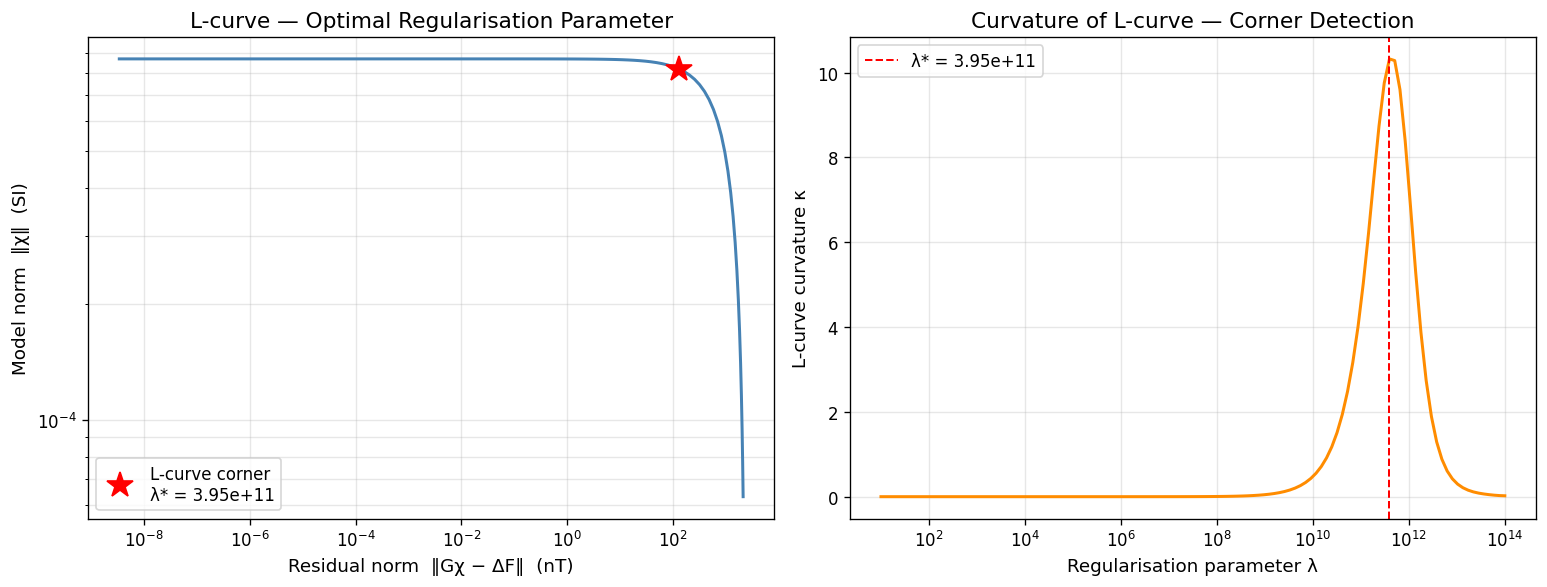

In [ ]:
# SVD Decomposition & L-curve
# SVD of G
print("Computing SVD of G ...")
U, sv, Vt = np.linalg.svd(G, full_matrices=False)
Utd = U.T @ anomaly           # projected data
print(f" SVD complete: U{U.shape}, S{sv.shape}, Vᵀ{Vt.shape}")

# L-curve: sweep λ, compute residual and model norms
lambdas     = np.logspace(1, 14, 120)
residuals   = np.zeros(len(lambdas))
model_norms = np.zeros(len(lambdas))

for idx, lam in enumerate(lambdas):
    f_factors      = sv**2 / (sv**2 + lam)       # Tikhonov filter factors
    chi            = Vt.T @ (f_factors * Utd / sv)
    residuals[idx] = np.linalg.norm(G @ chi - anomaly)
    model_norms[idx] = np.linalg.norm(chi)

# L-curve corner: maximum curvature in log-log space
log_r = (np.log10(residuals)   - np.log10(residuals).min()
       ) / (np.log10(residuals).max() - np.log10(residuals).min())
log_m = (np.log10(model_norms) - np.log10(model_norms).min()
       ) / (np.log10(model_norms).max() - np.log10(model_norms).min())

xp = np.gradient(log_m);  yp = np.gradient(log_r)
xpp = np.gradient(xp);    ypp = np.gradient(yp)
kappa = np.abs(xp*ypp - yp*xpp) / (xp**2 + yp**2 + 1e-12)**1.5
kappa_smooth = uniform_filter1d(kappa, size=5)

best_idx = np.argmax(kappa_smooth)
best_lam = lambdas[best_idx]

print(f"\n Optimal regularisation parameter  λ* = {best_lam:.3e}")
print(f"   Residual norm at λ* : {residuals[best_idx]:.3f} nT")
print(f"   Observed data RMS   : {np.sqrt(np.mean(anomaly**2)):.3f} nT")

# Plot L-curve
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].loglog(residuals, model_norms, 'steelblue', lw=1.8, zorder=2)
axes[0].loglog(residuals[best_idx], model_norms[best_idx],
               'r*', ms=16, zorder=5, label=f'L-curve corner\nλ* = {best_lam:.2e}')
axes[0].set_xlabel("Residual norm  ‖Gχ − ΔF‖  (nT)")
axes[0].set_ylabel("Model norm  ‖χ‖  (SI)")
axes[0].set_title("L-curve — Optimal Regularisation Parameter")
axes[0].legend(fontsize=10)
axes[0].grid(True, which='both', alpha=0.3)

axes[1].semilogx(lambdas, kappa_smooth, color='darkorange', lw=1.8)
axes[1].axvline(best_lam, color='red', ls='--', lw=1.2, label=f'λ* = {best_lam:.2e}')
axes[1].set_xlabel("Regularisation parameter λ")
axes[1].set_ylabel("L-curve curvature κ")
axes[1].set_title("Curvature of L-curve — Corner Detection")
axes[1].legend(fontsize=10)
axes[1].grid(True, which='both', alpha=0.3)

plt.tight_layout()
plt.show()


---
## Step 10 — Compute Susceptibility & Validate Fit

Apply the optimal $\lambda^*$ to compute the final susceptibility model $\chi^*$,
then **validate** by forward-modelling the predicted anomaly $G\chi^*$ and comparing
it with the observed $\Delta F$.


In [ ]:
# Apply Tikhonov filter with optimal λ
f_opt  = sv**2 / (sv**2 + best_lam)           # optimal filter factors
chi_opt = Vt.T @ (f_opt * Utd / sv)           # susceptibility vector (SI)
chi_2d  = chi_opt.reshape(n_obs, n_layers)     # reshape to 2D section

# Forward model: predicted anomaly
pred_anomaly = G @ chi_opt

# Fit statistics
residual_rms  = np.sqrt(np.mean((pred_anomaly - anomaly)**2))
obs_rms       = np.sqrt(np.mean(anomaly**2))
fit_quality   = (1 - residual_rms / obs_rms) * 100

print("  INVERSION RESULT SUMMARY \n")
print(f"  Regularisation λ*  : {best_lam:.3e}")
print(f"  Susceptibility χ   : {chi_opt.min():.3e} – {chi_opt.max():.3e}  SI")
print(f"  χ range (×10⁻³)    : {chi_opt.min()*1e3:.4f} – {chi_opt.max()*1e3:.4f}  ×10⁻³ SI")
print(f"  Observed RMS       : {obs_rms:.3f} nT")
print(f"  Residual RMS       : {residual_rms:.3f} nT")
print(f"  Fit quality        : {fit_quality:.1f}%")
print()
print("  Rock susceptibility reference:")
print("  Air / water          : ~0")
print("  Sedimentary rock     : 1×10⁻⁵ – 1×10⁻³ SI")
print("  Granite              : 1×10⁻⁴ – 5×10⁻³ SI")
print("  Basalt / mafic rock  : 1×10⁻³ – 1×10⁻¹ SI")
print("  Magnetite-rich ore   : 0.1 – 1 SI")



  INVERSION RESULT SUMMARY 

  Regularisation λ*  : 3.950e+11
  Susceptibility χ   : -1.763e-04 – 7.810e-05  SI
  χ range (×10⁻³)    : -0.1763 – 0.0781  ×10⁻³ SI
  Observed RMS       : 231.346 nT
  Residual RMS       : 12.735 nT
  Fit quality        : 94.5%

  Rock susceptibility reference:
  Air / water          : ~0
  Sedimentary rock     : 1×10⁻⁵ – 1×10⁻³ SI
  Granite              : 1×10⁻⁴ – 5×10⁻³ SI
  Basalt / mafic rock  : 1×10⁻³ – 1×10⁻¹ SI
  Magnetite-rich ore   : 0.1 – 1 SI


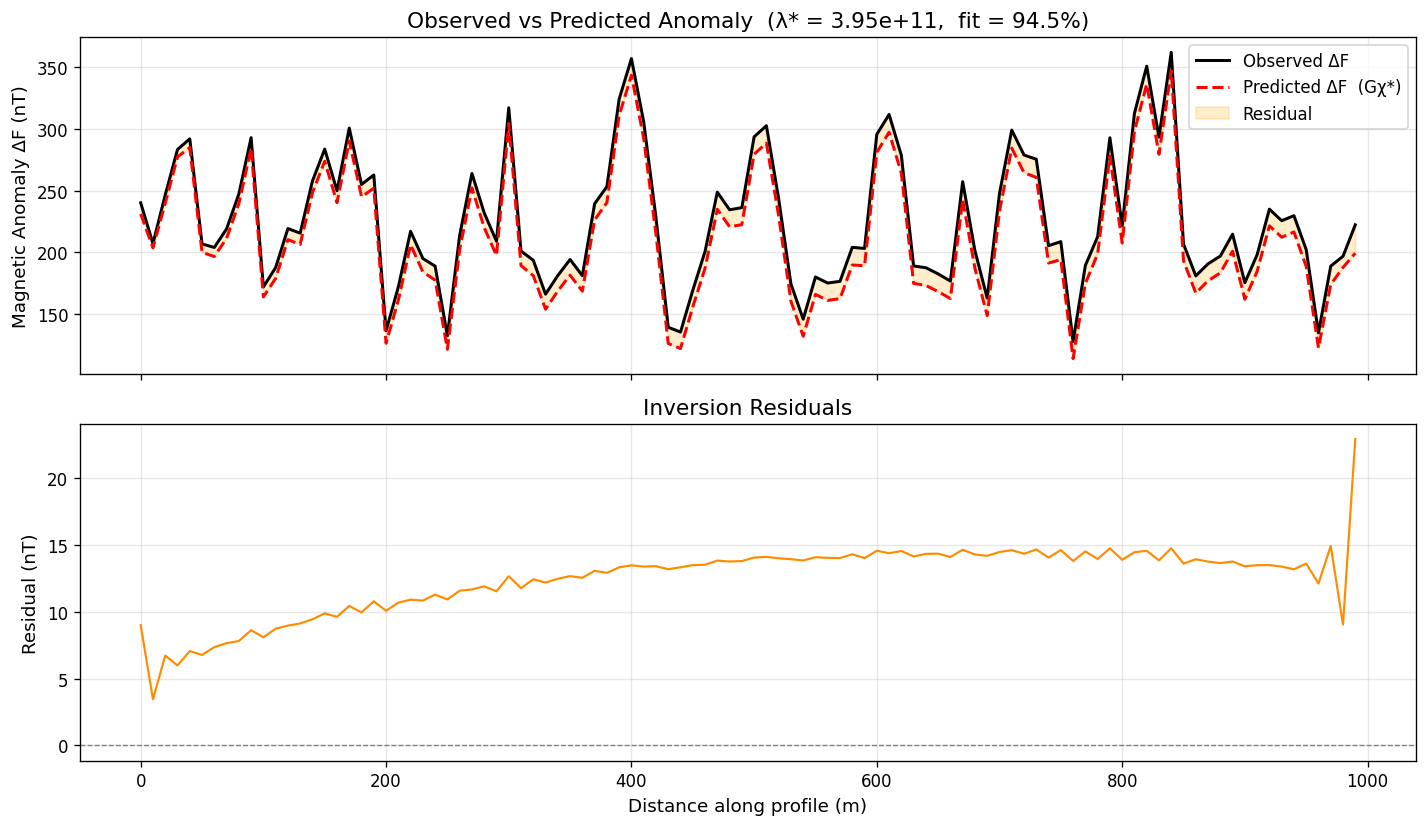

In [ ]:
# Observed vs Predicted anomaly
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(x_obs, anomaly, 'k-', lw=1.8, label='Observed ΔF')
axes[0].plot(x_obs, pred_anomaly, 'r--', lw=1.8, label='Predicted ΔF  (Gχ*)')
axes[0].fill_between(x_obs, anomaly, pred_anomaly,
                      alpha=0.2, color='orange', label='Residual')
axes[0].set_ylabel("Magnetic Anomaly ΔF (nT)")
axes[0].set_title(f"Observed vs Predicted Anomaly  (λ* = {best_lam:.2e},  fit = {fit_quality:.1f}%)")
axes[0].legend(fontsize=10)

axes[1].plot(x_obs, anomaly - pred_anomaly, color='darkorange', lw=1.3)
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel("Distance along profile (m)")
axes[1].set_ylabel("Residual (nT)")
axes[1].set_title("Inversion Residuals")

plt.tight_layout()
plt.show()


---
## Step 10B — Susceptibility Cross-Section (Tikhonov)

The susceptibility **cross-section** shows χ as a function of both
**horizontal distance along the 1D profile** (x-axis) and **depth** (y-axis).
This is a genuine physical model — each column in the grid represents the
subsurface directly below one survey station. The horizontal axis is the
same 1D profile; depth is added by the inversion model parameterisation.


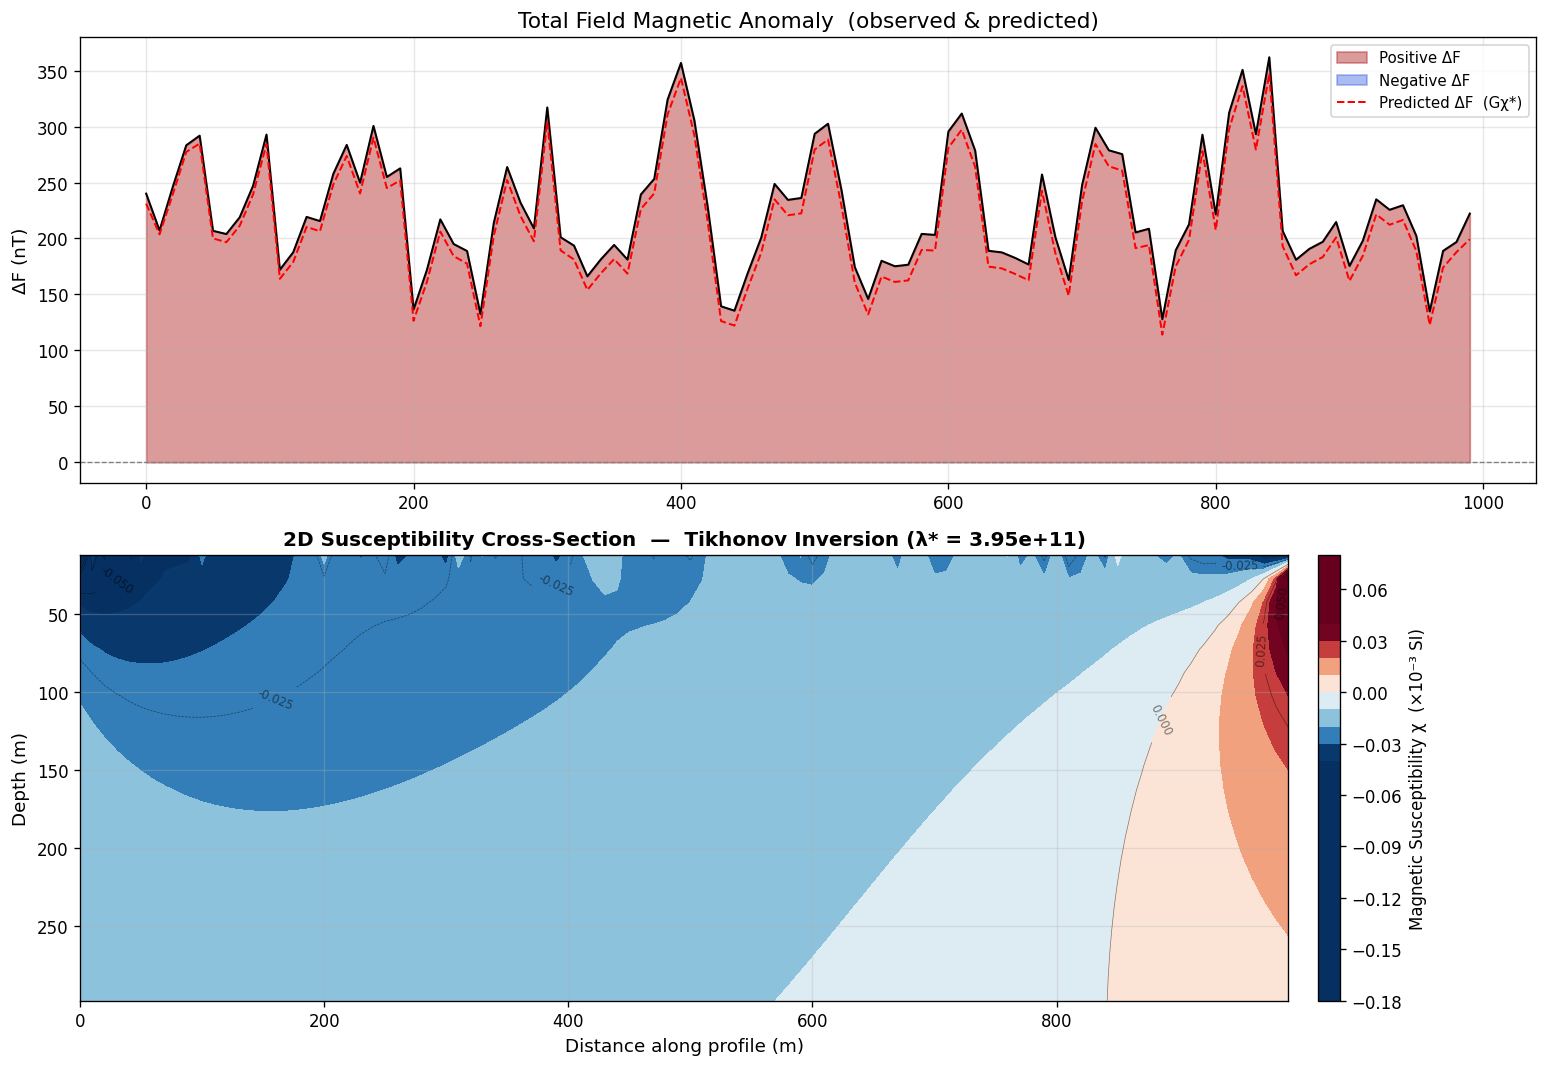

Susceptibility range: -0.1763 – 0.0781  ×10⁻³ SI
Max anomaly at depth: 12.5 m


In [ ]:
from matplotlib.colors import TwoSlopeNorm

chi_milli = chi_2d * 1e3     # convert SI → ×10⁻³ SI for display

X_plot, Z_plot = np.meshgrid(x_obs, z_mid)

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Top: Observed anomaly profile vs distance
axes[0].fill_between(x_obs, anomaly, 0,
                     where=(anomaly >= 0), color='firebrick', alpha=0.45,
                     label='Positive ΔF', interpolate=True)
axes[0].fill_between(x_obs, anomaly, 0,
                     where=(anomaly < 0), color='royalblue', alpha=0.45,
                     label='Negative ΔF', interpolate=True)
axes[0].plot(x_obs, anomaly, 'k-', lw=1.2)
axes[0].plot(x_obs, pred_anomaly, 'r--', lw=1.2, label='Predicted ΔF  (Gχ*)')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel("ΔF (nT)")
axes[0].set_title("Total Field Magnetic Anomaly  (observed & predicted)")
axes[0].legend(fontsize=9)

# Bottom: Susceptibility depth cross-section
vmax = np.percentile(np.abs(chi_milli), 98)
norm_chi = TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax)
cf = axes[1].contourf(X_plot, Z_plot, chi_milli.T,
                       levels=30, cmap='RdBu_r', norm=norm_chi)
cs = axes[1].contour(X_plot, Z_plot, chi_milli.T,
                      levels=10, colors='black', linewidths=0.4, alpha=0.5)
axes[1].clabel(cs, inline=True, fontsize=7, fmt='%.3f')
axes[1].invert_yaxis()

cbar = fig.colorbar(cf, ax=axes[1], pad=0.02)
cbar.set_label("Magnetic Susceptibility χ  (×10⁻³ SI)", fontsize=10)

axes[1].set_xlabel("Distance along profile (m)", fontsize=11)
axes[1].set_ylabel("Depth (m)", fontsize=11)
axes[1].set_title(
    f"2D Susceptibility Cross-Section  —  Tikhonov Inversion (λ* = {best_lam:.2e})",
    fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig("Total Field Magnetic Anomaly.png", dpi=150, bbox_inches='tight')
plt.show()

print(f"Susceptibility range: {chi_milli.min():.4f} – {chi_milli.max():.4f}  ×10⁻³ SI")
print(f"Max anomaly at depth: {z_mid[np.unravel_index(np.abs(chi_2d).argmax(), chi_2d.shape)[1]]:.1f} m")


---
---
# Part B — Forward Equation Analysis & Li & Oldenburg Depth-Weighted Inversion

---
## Step 11 — The Forward Equation: Origin, Linearisation & Problem Structure



$$\boxed{\Delta F_i = \sum_{j=1}^{N} G_{ij}\,\chi_j \;\Longleftrightarrow\; \mathbf{G}\boldsymbol{\chi} = \boldsymbol{\Delta F}}$$



In [ ]:
from scipy.ndimage import uniform_filter1d
from matplotlib.gridspec import GridSpec

print("=" * 62)
print("  FORWARD EQUATION:  G · χ = ΔF")
print("=" * 62)
print(f"  G shape     : {G.shape}  (obs × unknowns)")
print(f"  Underdetermined ratio : {n_model // n_obs}×  ({n_model} unknowns / {n_obs} obs)")
print(f"  Condition number      : {sv[0]/sv[-1]:.2f}")
print(f"  ΔF / F₀               : {np.abs(anomaly).max()/F0*100:.4f}%")
print(f"  Linearisation valid   : ✓  (χ ≪ 1, ΔF/F₀ ≪ 1)")
print()
print("  Three linearising assumptions used:")
print("  1. Induced magnetisation only  → M = χ · H₀  (linear in χ)")
print("  2. Weak susceptibility          → no self-demagnetisation feedback")
print("  3. Total-field approximation    → ΔF ≈ B̂₀ · B_anom  (scalar)")
print()
print("  G is built once from geometry + field direction.")
print("  It does NOT change during inversion  → purely linear problem.")
print("=" * 62)


  FORWARD EQUATION:  G · χ = ΔF
  G shape     : (100, 2000)  (obs × unknowns)
  Underdetermined ratio : 20×  (2000 unknowns / 100 obs)
  Condition number      : 5.53
  ΔF / F₀               : 0.7760%
  Linearisation valid   : ✓  (χ ≪ 1, ΔF/F₀ ≪ 1)

  Three linearising assumptions used:
  1. Induced magnetisation only  → M = χ · H₀  (linear in χ)
  2. Weak susceptibility          → no self-demagnetisation feedback
  3. Total-field approximation    → ΔF ≈ B̂₀ · B_anom  (scalar)

  G is built once from geometry + field direction.
  It does NOT change during inversion  → purely linear problem.


---
## Step 11 B — Method 2: Li & Oldenburg Depth-Weighted Inversion (1996)


| | Tikhonov L2 | Li & Oldenburg (1996) |
|---|---|---|
| Penalises | $\sum_j \chi_j^2$ | $\sum_j w_j^{-2}\chi_j^2 = \sum_j (z_j+z_0)^{\beta}\chi_j^2$ |
| Depth bias | Shallow preferred | Depth-equalised |
| Extra parameter | None | $\beta$ (= 1 for 2D profile) |
| Reference | Tikhonov 1963 | Li & Oldenburg, *Geophysics* 61(2), 1996 |


Depth weighting:  β = 1.0,  z₀ = 5.0 m
  w range : 0.0575 (deepest) – 0.2390 (shallowest)
  Shallowest / deepest amplification factor: 4.2×

Computing SVD of G̃  ...
 SVD complete:  Ũ(100, 100),  S̃(100,),  Ṽᵀ(100, 2000)


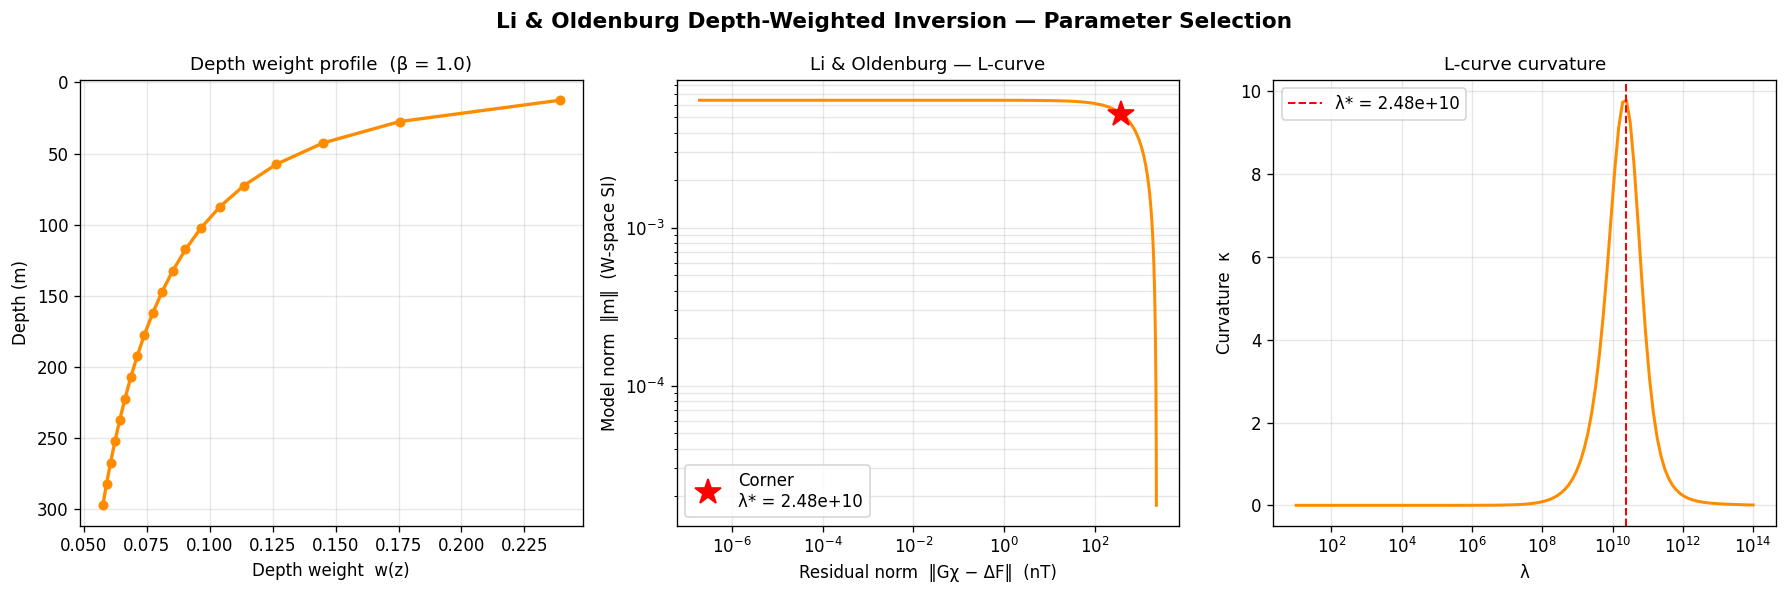


📍 Optimal λ* = 2.483e+10


In [ ]:
from matplotlib.colors import TwoSlopeNorm

# Depth weighting parameters
BETA = 1.0        # decay exponent for 2D total-field magnetic profile
Z0   = z_top[0]   # reference depth (top of shallowest layer, m)

# Build depth weight vector w_j = (z_mid[k] + z0)^(-β/2)
w_depth = np.zeros(n_model)
for j in range(n_obs):
    for k in range(n_layers):
        w_depth[j * n_layers + k] = (z_mid[k] + Z0) ** (-BETA / 2.0)

print(f"Depth weighting:  β = {BETA},  z₀ = {Z0:.1f} m")
print(f"  w range : {w_depth.min():.4f} (deepest) – {w_depth.max():.4f} (shallowest)")
print(f"  Shallowest / deepest amplification factor: {w_depth.max()/w_depth.min():.1f}×")

# Modified sensitivity matrix  G̃ = G · diag(w)
# Broadcasting avoids forming a dense n_model × n_model diagonal matrix
G_tilde = G * w_depth[np.newaxis, :]      # shape (n_obs, n_model)

# SVD of G̃
print("\nComputing SVD of G̃  ...")
U_dw, sv_dw, Vt_dw = np.linalg.svd(G_tilde, full_matrices=False)
Utd_dw = U_dw.T @ anomaly                 # projected data in modified space
print(f" SVD complete:  Ũ{U_dw.shape},  S̃{sv_dw.shape},  Ṽᵀ{Vt_dw.shape}")

# L-curve sweep
lambdas_dw   = np.logspace(1, 14, 120)
res_dw_arr   = np.zeros(len(lambdas_dw))
mn_dw_arr    = np.zeros(len(lambdas_dw))
chis_dw_list = []

for idx, lam in enumerate(lambdas_dw):
    f_fac   = sv_dw**2 / (sv_dw**2 + lam)          # Tikhonov filter on G̃
    m_sol   = Vt_dw.T @ (f_fac * Utd_dw / sv_dw)   # solution in m-space
    chi_sol = m_sol * w_depth                         # χ* = W · m*
    res_dw_arr[idx] = np.linalg.norm(G @ chi_sol - anomaly)   # misfit (original G)
    mn_dw_arr[idx]  = np.linalg.norm(m_sol)
    chis_dw_list.append(chi_sol)

# L-curve corner
log_r_dw = (np.log10(res_dw_arr) - np.log10(res_dw_arr).min()) / (np.log10(res_dw_arr).max() - np.log10(res_dw_arr).min())
log_m_dw = (np.log10(mn_dw_arr)  - np.log10(mn_dw_arr).min())  / (np.log10(mn_dw_arr).max()  - np.log10(mn_dw_arr).min())
xp_dw = np.gradient(log_m_dw);  yp_dw = np.gradient(log_r_dw)
kappa_dw = uniform_filter1d(
    np.abs(xp_dw*np.gradient(yp_dw) - yp_dw*np.gradient(xp_dw)) / (xp_dw**2+yp_dw**2+1e-12)**1.5,
    size=5)
best_dw_idx = np.argmax(kappa_dw)
best_lam_dw = lambdas_dw[best_dw_idx]

# L-curve plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# (a) Depth weighting profile
axes[0].plot(w_depth[:n_layers], z_mid, 'o-', color='darkorange', lw=2, ms=5)
axes[0].invert_yaxis()
axes[0].set_xlabel("Depth weight  w(z)",  fontsize=10)
axes[0].set_ylabel("Depth (m)",           fontsize=10)
axes[0].set_title(f"Depth weight profile  (β = {BETA})",   fontsize=11)
axes[0].grid(True, alpha=0.3)

# (b) L-curve
axes[1].loglog(res_dw_arr, mn_dw_arr, color='darkorange', lw=1.8)
axes[1].loglog(res_dw_arr[best_dw_idx], mn_dw_arr[best_dw_idx],
               'r*', ms=16, zorder=5, label=f'Corner\nλ* = {best_lam_dw:.2e}')
axes[1].set_xlabel("Residual norm  ‖Gχ − ΔF‖  (nT)", fontsize=10)
axes[1].set_ylabel("Model norm  ‖m‖  (W-space SI)", fontsize=10)
axes[1].set_title("Li & Oldenburg — L-curve",         fontsize=11)
axes[1].legend(fontsize=10);  axes[1].grid(True, which='both', alpha=0.3)

# (c) Curvature
axes[2].semilogx(lambdas_dw, kappa_dw, color='darkorange', lw=1.8)
axes[2].axvline(best_lam_dw, color='red', ls='--', lw=1.2, label=f'λ* = {best_lam_dw:.2e}')
axes[2].set_xlabel("λ",                   fontsize=10)
axes[2].set_ylabel("Curvature  κ",        fontsize=10)
axes[2].set_title("L-curve curvature",    fontsize=11)
axes[2].legend(fontsize=10);  axes[2].grid(True, which='both', alpha=0.3)

plt.suptitle("Li & Oldenburg Depth-Weighted Inversion — Parameter Selection",
             fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()
print(f"\n📍 Optimal λ* = {best_lam_dw:.3e}")


---
## Step 11 C — Li & Oldenburg: Result & Validation


  Li & Oldenburg INVERSION RESULT
  β (depth exponent)         : 1.0
  z₀ (reference depth)       : 5.0 m
  Optimal λ*                 : 2.483e+10
  χ range                    : -2.591e-04 – 1.194e-04  SI
  χ range  (×10⁻⁵ SI)        : -25.9060 – 11.9415
  Residual RMS               : 38.667 nT
  Observed RMS               : 231.346 nT

  Depth profile (station 50) — Tikhonov vs Li & Oldenburg:
     Depth       Tikhonov      Li & Old.
  z=   12m       -2.6079       -7.4119
  z=   58m       -1.9258       -1.7520
  z=  102m       -1.7652       -0.9193
  z=  148m       -1.6136       -0.5821
  z=  192m       -1.4640       -0.4016
  z=  238m       -1.3208       -0.2912
  z=  282m       -1.1872       -0.2183


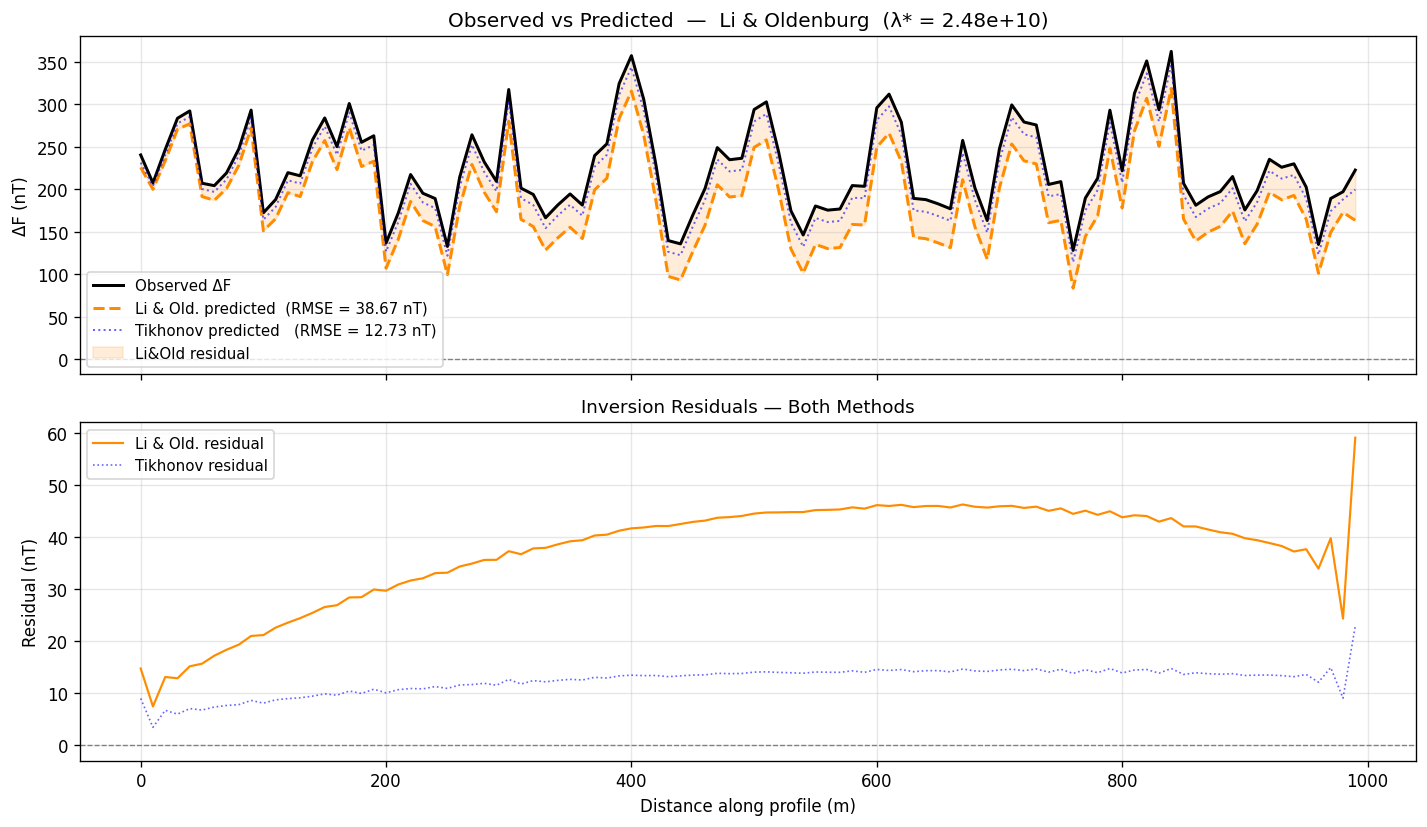

In [ ]:
# Optimal solution
f_opt_dw    = sv_dw**2 / (sv_dw**2 + best_lam_dw)
m_opt_dw    = Vt_dw.T @ (f_opt_dw * Utd_dw / sv_dw)
chi_dw_opt  = m_opt_dw * w_depth          # χ* = W · m*  back in physical space
chi_dw_2d   = chi_dw_opt.reshape(n_obs, n_layers)
pred_dw     = G @ chi_dw_opt

# Statistics
rmse_dw   = np.sqrt(np.mean((pred_dw - anomaly)**2))
obs_rms   = np.sqrt(np.mean(anomaly**2))

print("=" * 58)
print("  Li & Oldenburg INVERSION RESULT")
print("=" * 58)
print(f"  β (depth exponent)         : {BETA}")
print(f"  z₀ (reference depth)       : {Z0:.1f} m")
print(f"  Optimal λ*                 : {best_lam_dw:.3e}")
print(f"  χ range                    : {chi_dw_opt.min():.3e} – {chi_dw_opt.max():.3e}  SI")
print(f"  χ range  (×10⁻⁵ SI)        : {chi_dw_opt.min()*1e5:.4f} – {chi_dw_opt.max()*1e5:.4f}")
print(f"  Residual RMS               : {rmse_dw:.3f} nT")
print(f"  Observed RMS               : {obs_rms:.3f} nT")
print("=" * 58)
print()
print("  Depth profile (station 50) — Tikhonov vs Li & Oldenburg:")
print(f"  {'Depth':>8} {'Tikhonov':>14} {'Li & Old.':>14}")
for k in range(0, n_layers, 3):
    ct = chi_2d[n_obs//2, k] * 1e5
    cd = chi_dw_2d[n_obs//2, k] * 1e5
    print(f"  z={z_mid[k]:5.0f}m  {ct:12.4f}  {cd:12.4f}")

# Observed vs Predicted anomaly
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(x_obs, anomaly,  'k-',  lw=1.8, label='Observed ΔF')
axes[0].plot(x_obs, pred_dw,  color='darkorange', ls='--', lw=1.8,
             label=f'Li & Old. predicted  (RMSE = {rmse_dw:.2f} nT)')
axes[0].plot(x_obs, pred_anomaly, 'b:', lw=1.2, alpha=0.6,
             label=f'Tikhonov predicted   (RMSE = {residual_rms:.2f} nT)')
axes[0].fill_between(x_obs, anomaly, pred_dw, alpha=0.15, color='darkorange', label='Li&Old residual')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel("ΔF (nT)",    fontsize=10)
axes[0].set_title(f"Observed vs Predicted  —  Li & Oldenburg  (λ* = {best_lam_dw:.2e})",
                   fontsize=12)
axes[0].legend(fontsize=9)

axes[1].plot(x_obs, anomaly - pred_dw, color='darkorange', lw=1.3, label='Li & Old. residual')
axes[1].plot(x_obs, anomaly - pred_anomaly, 'b:', lw=1.0, alpha=0.6, label='Tikhonov residual')
axes[1].axhline(0, color='gray', ls='--', lw=0.8)
axes[1].set_xlabel("Distance along profile (m)", fontsize=10)
axes[1].set_ylabel("Residual (nT)",  fontsize=10)
axes[1].set_title("Inversion Residuals — Both Methods",  fontsize=11)
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.show()


---
## Step 11 D — Li & Oldenburg: Susceptibility Cross-Section


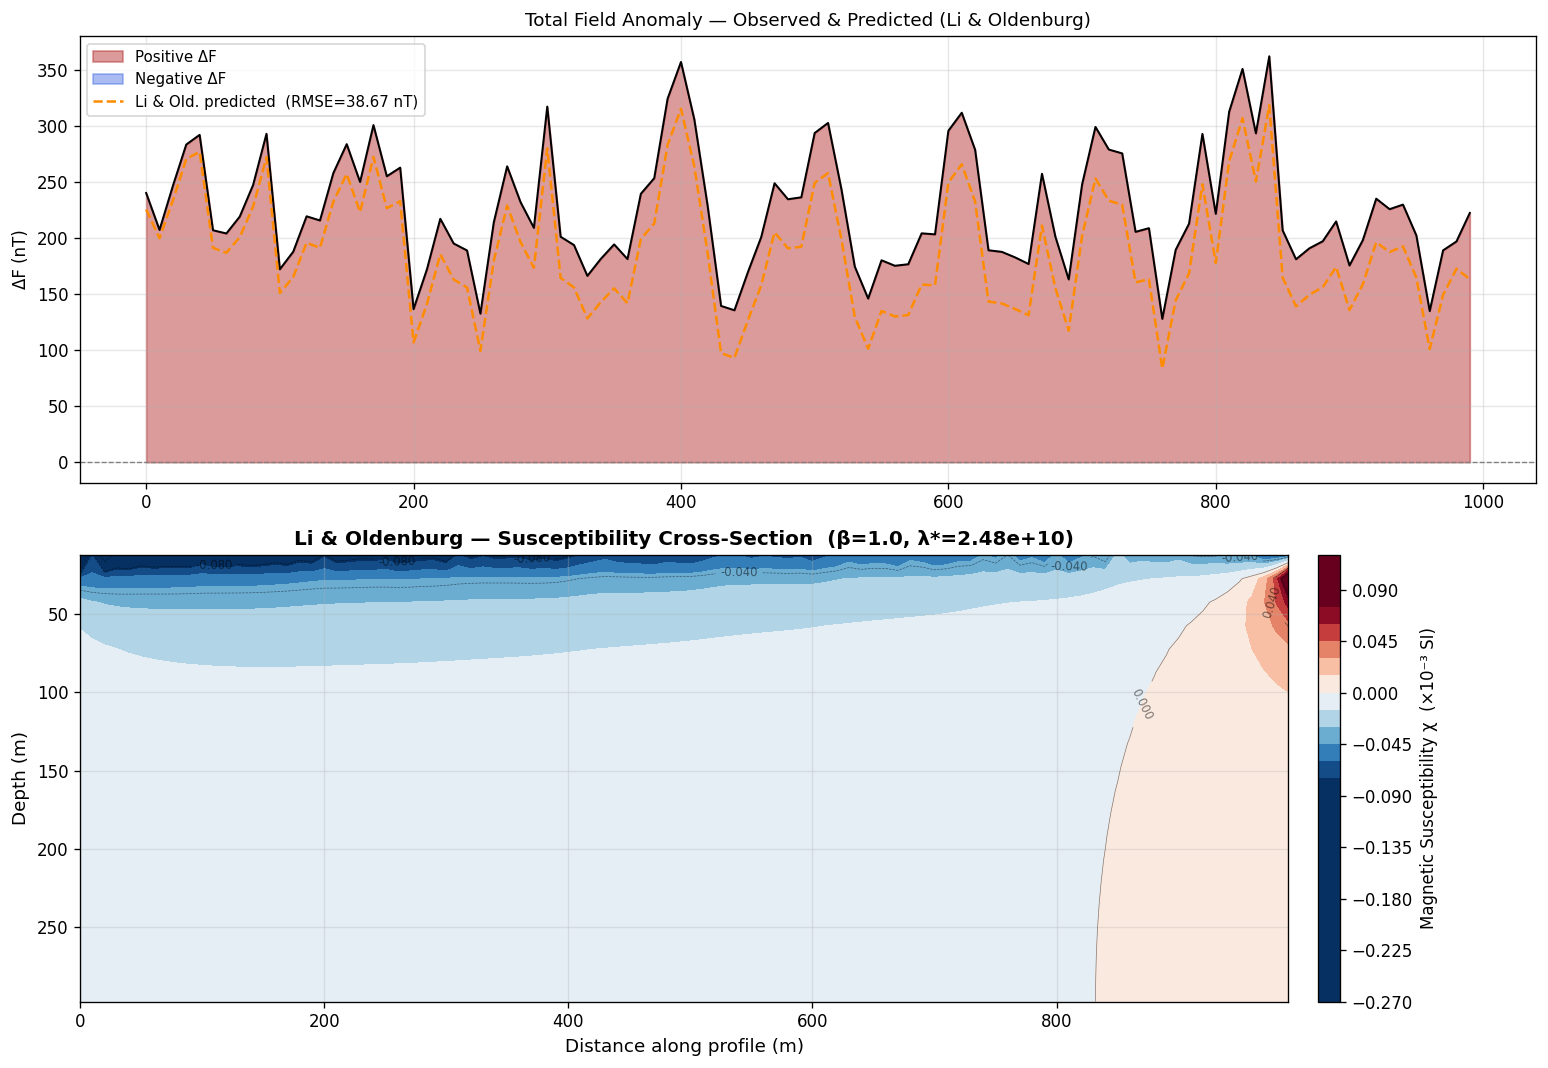

χ range  (×10⁻³ SI): -0.2591 – 0.1194
Deepest significant anomaly at: 12.5 m


In [ ]:
X_plot_dw, Z_plot_dw = np.meshgrid(x_obs, z_mid)
chi_dw_milli = chi_dw_2d * 1e3   # SI → ×10⁻³ SI

fig, axes = plt.subplots(2, 1, figsize=(13, 9))

# Top: anomaly
axes[0].fill_between(x_obs, anomaly, 0,
                     where=(anomaly >= 0), color='firebrick', alpha=0.45,
                     label='Positive ΔF', interpolate=True)
axes[0].fill_between(x_obs, anomaly, 0,
                     where=(anomaly < 0), color='royalblue', alpha=0.45,
                     label='Negative ΔF', interpolate=True)
axes[0].plot(x_obs, anomaly,  'k-',            lw=1.2)
axes[0].plot(x_obs, pred_dw,  color='darkorange', ls='--', lw=1.5,
             label=f'Li & Old. predicted  (RMSE={rmse_dw:.2f} nT)')
axes[0].axhline(0, color='gray', ls='--', lw=0.8)
axes[0].set_ylabel("ΔF (nT)",  fontsize=10)
axes[0].set_title("Total Field Anomaly — Observed & Predicted (Li & Oldenburg)", fontsize=11)
axes[0].legend(fontsize=9)

# Bottom: χ cross-section
vmax_dw  = np.percentile(np.abs(chi_dw_milli), 98)
norm_dw  = TwoSlopeNorm(vmin=-vmax_dw, vcenter=0, vmax=vmax_dw)
cf = axes[1].contourf(X_plot_dw, Z_plot_dw, chi_dw_milli.T,
                       levels=30, cmap='RdBu_r', norm=norm_dw)
cs = axes[1].contour(X_plot_dw, Z_plot_dw, chi_dw_milli.T,
                      levels=10, colors='black', linewidths=0.4, alpha=0.5)
axes[1].clabel(cs, inline=True, fontsize=7, fmt='%.3f')
axes[1].invert_yaxis()

cbar = fig.colorbar(cf, ax=axes[1], pad=0.02)
cbar.set_label("Magnetic Susceptibility χ  (×10⁻³ SI)", fontsize=10)
axes[1].set_xlabel("Distance along profile (m)", fontsize=11)
axes[1].set_ylabel("Depth (m)",                   fontsize=11)
axes[1].set_title(
    f"Li & Oldenburg — Susceptibility Cross-Section  (β={BETA}, λ*={best_lam_dw:.2e})",
    fontsize=12, fontweight='bold')

plt.tight_layout(); plt.show()

print(f"χ range  (×10⁻³ SI): {chi_dw_milli.min():.4f} – {chi_dw_milli.max():.4f}")
print(f"Deepest significant anomaly at: {z_mid[np.unravel_index(np.abs(chi_dw_2d).argmax(), chi_dw_2d.shape)[1]]:.1f} m")


---
## Step 12 — Final Comparison: Tikhonov vs Li & Oldenburg


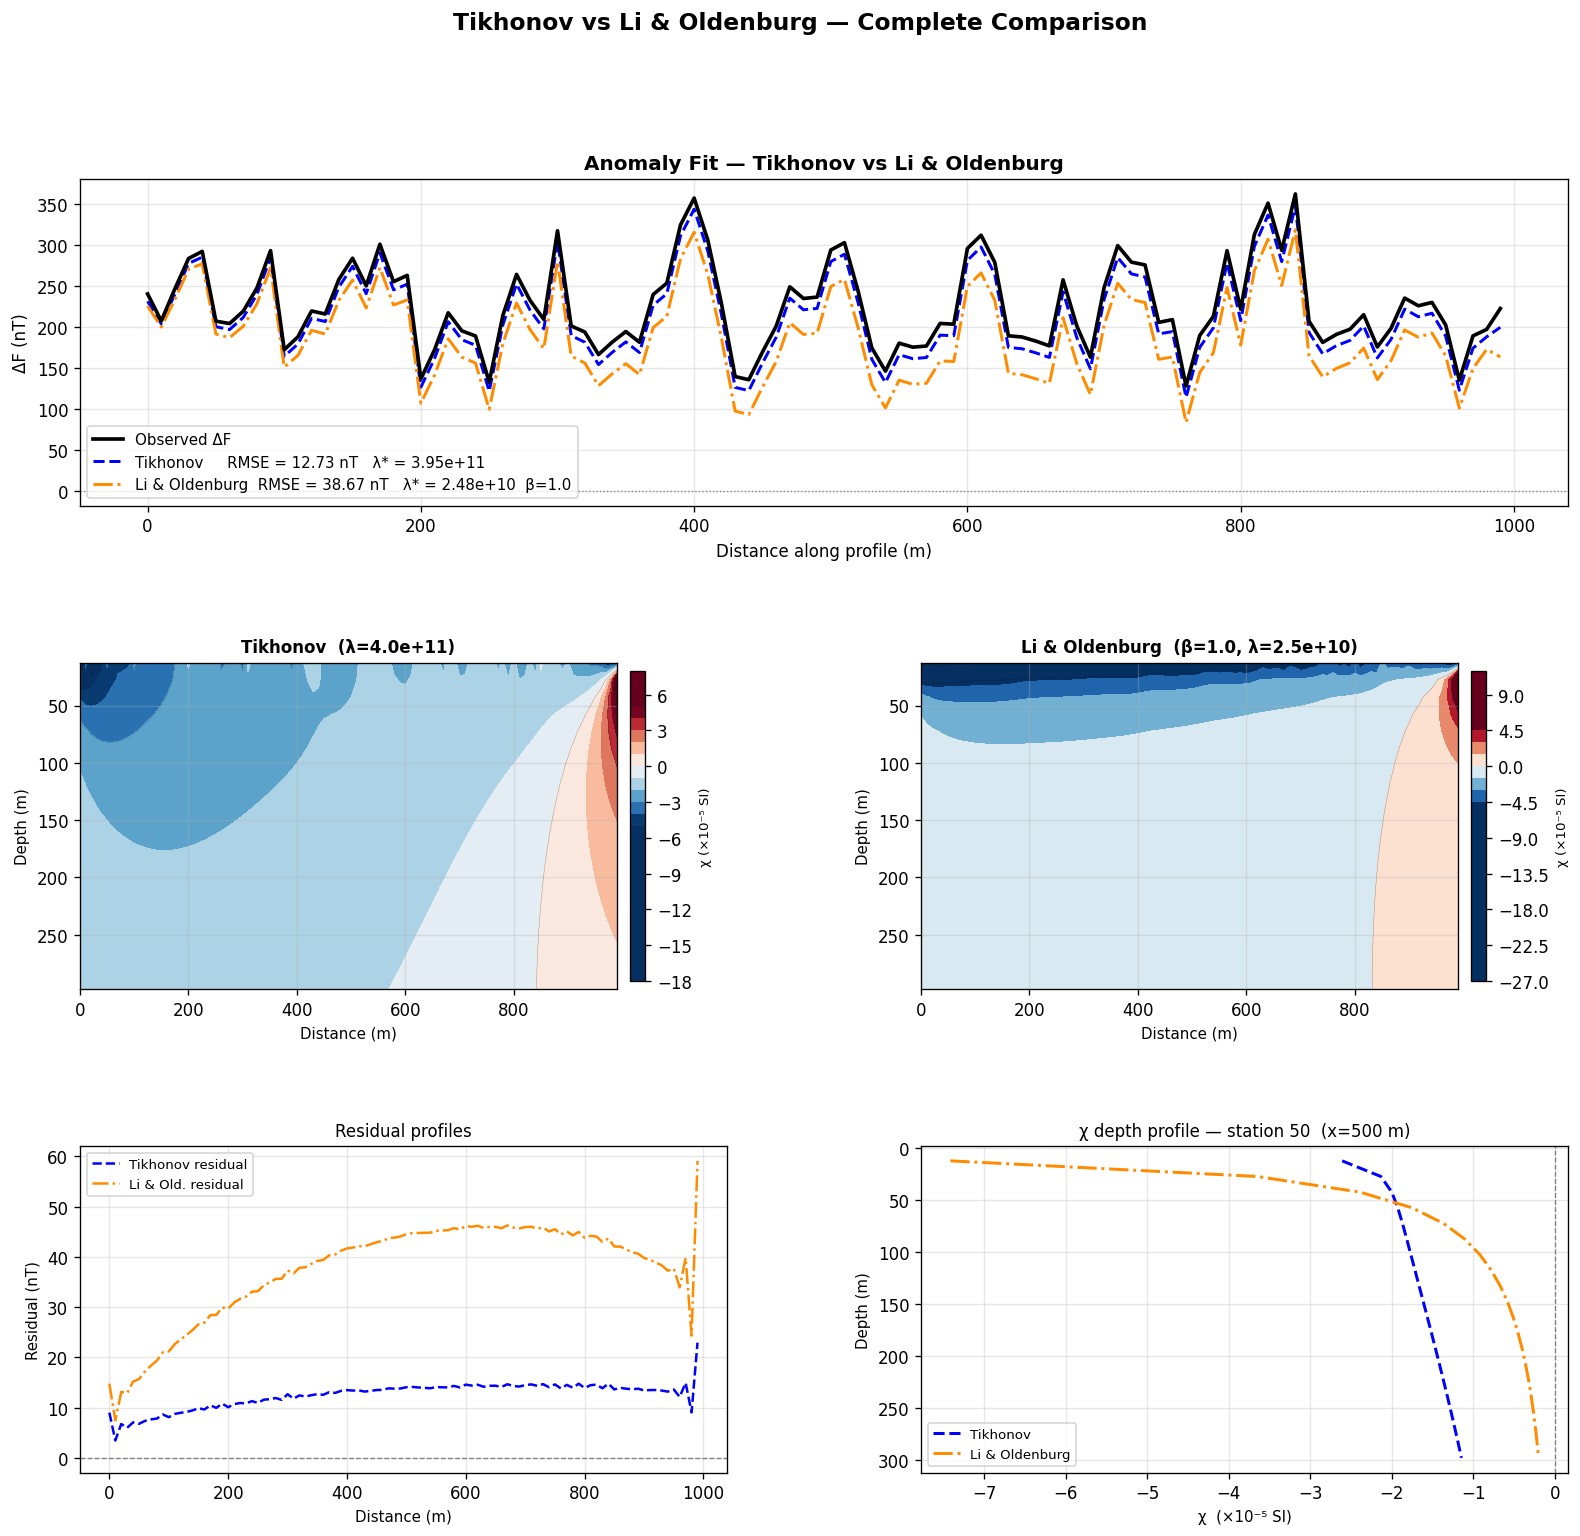

Comparison figure saved.

  FINAL BENCHMARK
  Method                       RMSE (nT)       R²    χ min ×10⁻⁵    χ max ×10⁻⁵
  -------------------------------------------------------------------------
  Tikhonov                        12.735   0.9414       -17.6304         7.8104
  Li & Oldenburg                  38.667   0.4594       -25.9060        11.9415


In [ ]:
from matplotlib.gridspec import GridSpec
from sklearn.metrics import r2_score

fig = plt.figure(figsize=(16, 14))
gs  = GridSpec(3, 2, figure=fig, hspace=0.48, wspace=0.30)

# Row 0: Anomaly fits (1D profile)
ax_top = fig.add_subplot(gs[0, :])
ax_top.plot(x_obs, anomaly,  'k-',  lw=2.2, label='Observed ΔF', zorder=5)
ax_top.plot(x_obs, pred_anomaly, 'b--', lw=1.8,
            label=f'Tikhonov     RMSE = {residual_rms:.2f} nT   λ* = {best_lam:.2e}')
ax_top.plot(x_obs, pred_dw,  color='darkorange', ls='-.', lw=1.8,
            label=f'Li & Oldenburg  RMSE = {rmse_dw:.2f} nT   λ* = {best_lam_dw:.2e}  β={BETA}')
ax_top.axhline(0, color='gray', ls=':', lw=0.8)
ax_top.set_xlabel("Distance along profile (m)", fontsize=10)
ax_top.set_ylabel("ΔF (nT)", fontsize=10)
ax_top.set_title("Anomaly Fit — Tikhonov vs Li & Oldenburg", fontsize=12, fontweight='bold')
ax_top.legend(fontsize=9)

# Row 1: Susceptibility cross-sections (depth models)
vmax_cmp = np.percentile(np.abs(np.stack([chi_2d, chi_dw_2d]))*1e5, 97)
norm_cmp  = TwoSlopeNorm(vmin=-vmax_cmp, vcenter=0, vmax=vmax_cmp)
X_c, Z_c  = np.meshgrid(x_obs, z_mid)

for col, (chi_plot, title) in enumerate([
    (chi_2d,    f'Tikhonov  (λ={best_lam:.1e})'),
    (chi_dw_2d, f'Li & Oldenburg  (β={BETA}, λ={best_lam_dw:.1e})'),
]):
    ax = fig.add_subplot(gs[1, col])
    cf = ax.contourf(X_c, Z_c, chi_plot.T*1e5, levels=25, cmap='RdBu_r', norm=norm_cmp)
    ax.contour(X_c, Z_c, chi_plot.T*1e5, levels=8, colors='k', linewidths=0.25, alpha=0.4)
    ax.invert_yaxis()
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.set_xlabel("Distance (m)", fontsize=9)
    ax.set_ylabel("Depth (m)", fontsize=9)
    cbar_c = plt.colorbar(cf, ax=ax, pad=0.02, shrink=0.95)
    cbar_c.set_label("χ (×10⁻⁵ SI)", fontsize=8)

# Row 2: Residuals + depth profile at central station
ax_res = fig.add_subplot(gs[2, 0])
ax_res.plot(x_obs, anomaly - pred_anomaly, 'b--', lw=1.5, label='Tikhonov residual')
ax_res.plot(x_obs, anomaly - pred_dw, color='darkorange', ls='-.', lw=1.5, label='Li & Old. residual')
ax_res.axhline(0, color='gray', ls='--', lw=0.8)
ax_res.set_xlabel("Distance (m)", fontsize=9)
ax_res.set_ylabel("Residual (nT)", fontsize=9)
ax_res.set_title("Residual profiles", fontsize=10)
ax_res.legend(fontsize=8)

ax_depth = fig.add_subplot(gs[2, 1])
mid_s = n_obs // 2
ax_depth.plot(chi_2d[mid_s, :]*1e5,    z_mid, 'b--', lw=1.8, label='Tikhonov')
ax_depth.plot(chi_dw_2d[mid_s, :]*1e5, z_mid, color='darkorange', ls='-.', lw=1.8, label='Li & Oldenburg')
ax_depth.invert_yaxis()
ax_depth.axvline(0, color='gray', ls='--', lw=0.8)
ax_depth.set_xlabel("χ  (×10⁻⁵ SI)", fontsize=9)
ax_depth.set_ylabel("Depth (m)", fontsize=9)
ax_depth.set_title(f"χ depth profile — station {mid_s}  (x={x_obs[mid_s]:.0f} m)", fontsize=10)
ax_depth.legend(fontsize=8)

plt.suptitle("Tikhonov vs Li & Oldenburg — Complete Comparison", fontsize=14, fontweight='bold')
plt.savefig('mag_comparison_tikhonov_li_oldenburg.png', dpi=150, bbox_inches='tight')
plt.show()
print("Comparison figure saved.")

# Benchmark table
print("\n  FINAL BENCHMARK")
print(f"  {'Method':<25} {'RMSE (nT)':>12} {'R²':>8} {'χ min ×10⁻⁵':>14} {'χ max ×10⁻⁵':>14}")
print(f"  {'-'*73}")
for name, pred, chi in [('Tikhonov', pred_anomaly, chi_opt),
                         ('Li & Oldenburg', pred_dw, chi_dw_opt)]:
    rmse_v = np.sqrt(np.mean((pred-anomaly)**2))
    r2_v   = r2_score(anomaly, pred)
    print(f"  {name:<25} {rmse_v:>12.3f} {r2_v:>8.4f} {chi.min()*1e5:>14.4f} {chi.max()*1e5:>14.4f}")
